In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from funciones import derivadas, a_cartesiano

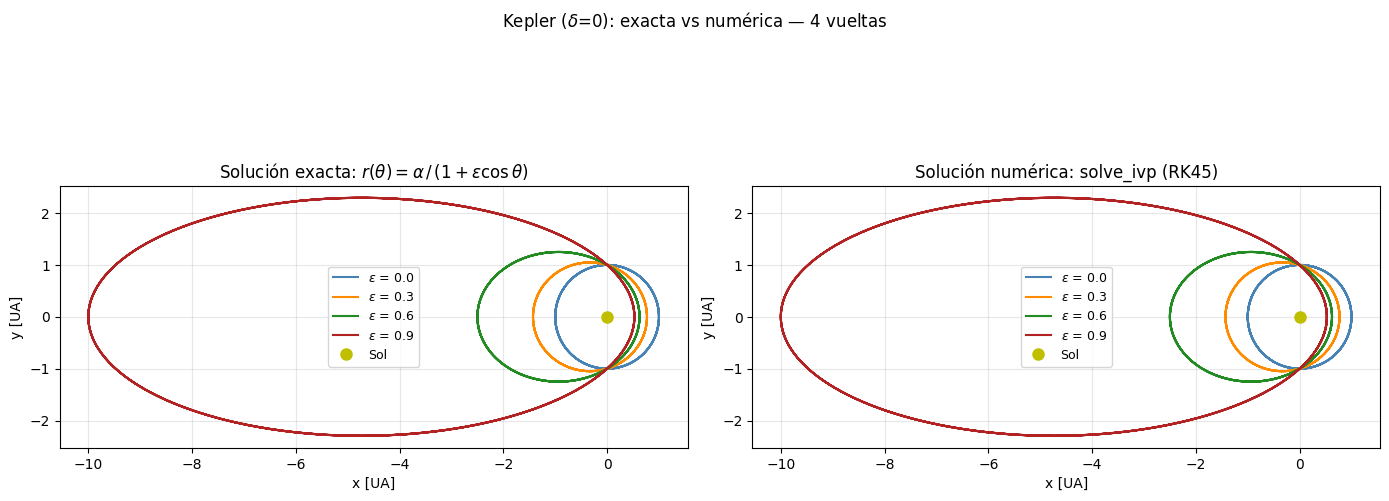

Error maximo |r_num - r_exacta| (primera vuelta completa):
  eps = 0.0   error = 0.0
  eps = 0.3   error = 7.340967833613377e-10
  eps = 0.6   error = 3.11821590770478e-09
  eps = 0.9   error = 5.6640832468701774e-08


In [8]:
ti_cmp = 0.0
tf_cmp = 4 * 2 * np.pi
lt_cmp = np.linspace(ti_cmp, tf_cmp, 5000)

alpha = 1.0
epsilons = [0.0, 0.3, 0.6, 0.9]
colores  = ['steelblue', 'darkorange', 'forestgreen', 'firebrick']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax1.set_aspect(1.0)
ax1.set_title(r'Solución exacta: $r(\theta) = \alpha\,/\,(1 + \varepsilon\cos\theta)$')

for i in range(len(epsilons)):
    eps   = epsilons[i]
    color = colores[i]

    r_ex = alpha / (1 + eps * np.cos(lt_cmp))
    x_ex = r_ex * np.cos(lt_cmp)
    y_ex = r_ex * np.sin(lt_cmp)

    ax1.plot(x_ex, y_ex, color=color, lw=1.5, label=r'$\varepsilon$ = ' + str(eps))

ax1.plot(0, 0, 'yo', ms=8, label='Sol', zorder=5)
ax1.legend(fontsize=9)
ax1.set_xlabel('x [UA]')
ax1.set_ylabel('y [UA]')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.set_aspect(1.0)
ax2.set_title('Solución numérica: solve_ivp (RK45)')

for i in range(len(epsilons)):
    eps   = epsilons[i]
    color = colores[i]

    estado_inicial = [(1 + eps) / alpha, 0.0]
    solucion = solve_ivp(derivadas, [ti_cmp, tf_cmp], estado_inicial,
                         t_eval=lt_cmp, args=(alpha, 0.0),
                         rtol=1e-9, atol=1e-11)

    xn, yn = a_cartesiano(solucion.t, solucion.y[0])
    ax2.plot(xn, yn, color=color, lw=1.5, label=r'$\varepsilon$ = ' + str(eps))

ax2.plot(0, 0, 'yo', ms=8, label='Sol', zorder=5)
ax2.legend(fontsize=9)
ax2.set_xlabel('x [UA]')
ax2.set_ylabel('y [UA]')
ax2.grid(True, alpha=0.3)

fig.suptitle(r'Kepler ($\delta$=0): exacta vs numérica — 4 vueltas')
plt.tight_layout()
plt.savefig(r'graficos\figura_4_sol_exacta_vs_numerica.png', dpi=120, bbox_inches='tight')
plt.show()

print('Error maximo |r_num - r_exacta| (primera vuelta completa):')

lt_err = np.linspace(0.0, 2 * np.pi, 2000)

for i in range(len(epsilons)):
    eps = epsilons[i]

    estado_inicial = [(1 + eps) / alpha, 0.0]
    sol = solve_ivp(derivadas, [0.0, 2 * np.pi], estado_inicial,
                    t_eval=lt_err, args=(alpha, 0.0),
                    rtol=1e-9, atol=1e-11)

    r_num   = 1.0 / sol.y[0]
    r_exact = alpha / (1 + eps * np.cos(sol.t))
    error   = np.max(np.abs(r_num - r_exact))
    print('  eps =', eps, '  error =', error)